In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# EDA - Fractal dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import cv2
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 8)

## Data load

In [ ]:
dataset_path = '/kaggle/input/fracatlas-original-dataset/FracAtlas'
print(f"\nDataset path: {dataset_path}")



Dataset path: /kaggle/input/fracatlas-original-dataset/FracAtlas


In [ ]:
csv_path = os.path.join(dataset_path, 'dataset.csv')
df = pd.read_csv(csv_path)

print(f"Dataset shape: {df.shape}")
print(f"Total images: {len(df)}")
print(f"\nColumn names ({len(df.columns)} columns):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nData types:")
print(df.dtypes)

print(f"\nMissing values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values!")
else:
    print(missing[missing > 0])

Dataset shape: (4083, 13)
Total images: 4083

Column names (13 columns):
  1. image_id
  2. hand
  3. leg
  4. hip
  5. shoulder
  6. mixed
  7. hardware
  8. multiscan
  9. fractured
  10. fracture_count
  11. frontal
  12. lateral
  13. oblique

First 5 rows:
         image_id  hand  leg  hip  shoulder  mixed  hardware  multiscan  \
0  IMG0000000.jpg     0    1    0         0      0         0          1   
1  IMG0000001.jpg     0    1    0         0      0         0          1   
2  IMG0000002.jpg     0    1    0         0      0         0          1   
3  IMG0000003.jpg     0    1    0         0      0         0          1   
4  IMG0000004.jpg     0    1    0         0      0         0          1   

   fractured  fracture_count  frontal  lateral  oblique  
0          0               0        1        1        0  
1          0               0        1        1        0  
2          0               0        1        1        0  
3          0               0        0        1        1

## Stats

In [ ]:
print(f"\nDataset Info:")
print(f"  Total Images: {len(df)}")
print(f"  Shape: {df.shape}")
print(f"\nNumerical Columns Summary:")
print(df.describe())


Dataset Info:
  Total Images: 4083
  Shape: (4083, 13)

Numerical Columns Summary:
              hand          leg          hip     shoulder        mixed  \
count  4083.000000  4083.000000  4083.000000  4083.000000  4083.000000   
mean      0.376684     0.556699     0.082782     0.085476     0.097477   
std       0.484614     0.496836     0.275587     0.279624     0.296643   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.000000     0.000000     0.000000     0.000000     0.000000   
50%       0.000000     1.000000     0.000000     0.000000     0.000000   
75%       1.000000     1.000000     0.000000     0.000000     0.000000   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

          hardware    multiscan    fractured  fracture_count      frontal  \
count  4083.000000  4083.000000  4083.000000     4083.000000  4083.000000   
mean      0.024247     0.096988     0.175606        0.225814     0.613030   
std       0.153834

## Class Distribution

In [ ]:
# Fracture distribution
fracture_dist = df['fractured'].value_counts().sort_index()
print(f"\nFRACTURE DISTRIBUTION:")
print(f"  Non-Fractured (0): {fracture_dist[0]:,} ({fracture_dist[0]/len(df)*100:.2f}%)")
print(f"  Fractured (1):     {fracture_dist[1]:,} ({fracture_dist[1]/len(df)*100:.2f}%)")
imbalance_ratio = fracture_dist[0] / fracture_dist[1]
print(f" Imbalance Ratio: {imbalance_ratio:.2f}:1 (SEVERE - needs handling!)")

# Fracture count
print(f"\nFRACTURE COUNT DISTRIBUTION:")
fracture_count_dist = df['fracture_count'].value_counts().sort_index()
print(fracture_count_dist)

# Body regions
print(f"\nBODY REGIONS COVERED:")
regions = ['hand', 'leg', 'hip', 'shoulder']
for region in regions:
    count = df[region].sum()
    pct = (count / len(df)) * 100
    print(f"  {region.capitalize():12s}: {int(count):,} images ({pct:5.2f}%)")

# Hardware presence
print(f"\n MEDICAL HARDWARE (Orthopedic devices):")
hardware_0 = (df['hardware'] == 0).sum()
hardware_1 = (df['hardware'] == 1).sum()
print(f"  Without hardware: {hardware_0:,} ({hardware_0/len(df)*100:.2f}%)")
print(f"  With hardware:    {hardware_1:,} ({hardware_1/len(df)*100:.2f}%)")

# Multiscan
print(f"\nMULTIPLE SCANS:")
multiscan_0 = (df['multiscan'] == 0).sum()
multiscan_1 = (df['multiscan'] == 1).sum()
print(f"  Single scan:   {multiscan_0:,} ({multiscan_0/len(df)*100:.2f}%)")
print(f"  Multi-scan:    {multiscan_1:,} ({multiscan_1/len(df)*100:.2f}%)")

# Mixed regions
print(f"\nMIXED REGIONS:")
mixed_0 = (df['mixed'] == 0).sum()
mixed_1 = (df['mixed'] == 1).sum()
print(f"  Single region: {mixed_0:,} ({mixed_0/len(df)*100:.2f}%)")
print(f"  Mixed regions: {mixed_1:,} ({mixed_1/len(df)*100:.2f}%)")

# Orientation
print(f"\nIMAGE ORIENTATION:")
frontal = df['frontal'].sum()
lateral = df['lateral'].sum()
oblique = df['oblique'].sum()
print(f"  Frontal:  {int(frontal):,} ({frontal/len(df)*100:.2f}%)")
print(f"  Lateral:  {int(lateral):,} ({lateral/len(df)*100:.2f}%)")
print(f"  Oblique:  {int(oblique):,} ({oblique/len(df)*100:.2f}%)")



FRACTURE DISTRIBUTION:
  Non-Fractured (0): 3,366 (82.44%)
  Fractured (1):     717 (17.56%)
 Imbalance Ratio: 4.69:1 (SEVERE - needs handling!)

FRACTURE COUNT DISTRIBUTION:
fracture_count
0    3366
1     546
2     146
3      17
4       7
5       1
Name: count, dtype: int64

BODY REGIONS COVERED:
  Hand        : 1,538 images (37.67%)
  Leg         : 2,273 images (55.67%)
  Hip         : 338 images ( 8.28%)
  Shoulder    : 349 images ( 8.55%)

 MEDICAL HARDWARE (Orthopedic devices):
  Without hardware: 3,984 (97.58%)
  With hardware:    99 (2.42%)

MULTIPLE SCANS:
  Single scan:   3,687 (90.30%)
  Multi-scan:    396 (9.70%)

MIXED REGIONS:
  Single region: 3,685 (90.25%)
  Mixed regions: 398 (9.75%)

IMAGE ORIENTATION:
  Frontal:  2,503 (61.30%)
  Lateral:  1,492 (36.54%)
  Oblique:  418 (10.24%)


## Detailed Cross tabulation

In [ ]:
print("\nFracture Status by Body Region:")
for region in regions:
    cross_tab = pd.crosstab(df['fractured'], df[region], margins=True)
    print(f"\n{region.upper()}:")
    print(cross_tab)

print("\nFracture Status by Hardware Presence:")
hw_crosstab = pd.crosstab(df['fractured'], df['hardware'], margins=True)
print(hw_crosstab)


Fracture Status by Body Region:

HAND:
hand          0     1   All
fractured                  
0          2266  1100  3366
1           279   438   717
All        2545  1538  4083

LEG:
leg           0     1   All
fractured                  
0          1356  2010  3366
1           454   263   717
All        1810  2273  4083

HIP:
hip           0    1   All
fractured                 
0          3091  275  3366
1           654   63   717
All        3745  338  4083

SHOULDER:
shoulder      0    1   All
fractured                 
0          3080  286  3366
1           654   63   717
All        3734  349  4083

Fracture Status by Hardware Presence:
hardware      0   1   All
fractured                
0          3364   2  3366
1           620  97   717
All        3984  99  4083


## Image Dir analysis

In [ ]:
fractured_path = os.path.join(dataset_path, 'images', 'Fractured')
non_fractured_path = os.path.join(dataset_path, 'images', 'Non_fractured')

fractured_files = [f for f in os.listdir(fractured_path) if f.endswith('.jpg')]
non_fractured_files = [f for f in os.listdir(non_fractured_path) if f.endswith('.jpg')]

print(f"\n Image File Counts:")
print(f"  Fractured folder:     {len(fractured_files):,} files")
print(f"  Non-fractured folder: {len(non_fractured_files):,} files")
print(f"  Total:                {len(fractured_files) + len(non_fractured_files):,} files")

# Verify with CSV
print(f"\n Verification with dataset.csv:")
print(f"  CSV fractured count: {fracture_dist[1]:,}")
print(f"  CSV non-fractured count: {fracture_dist[0]:,}")


 Image File Counts:
  Fractured folder:     717 files
  Non-fractured folder: 3,366 files
  Total:                4,083 files

 Verification with dataset.csv:
  CSV fractured count: 717
  CSV non-fractured count: 3,366


## Image property

In [ ]:
image_stats = {
    'width': [],
    'height': [],
    'channels': [],
    'file_size_kb': []
}

print("\nAnalyzing image properties:")

# fractured images
for img_file in fractured_files[:50]:
    img_path = os.path.join(fractured_path, img_file)
    img = cv2.imread(img_path)
    file_size = os.path.getsize(img_path) / 1024  # Convert to KB

    if img is not None:
        h, w, c = img.shape
        image_stats['height'].append(h)
        image_stats['width'].append(w)
        image_stats['channels'].append(c)
        image_stats['file_size_kb'].append(file_size)

# non-fractured images
for img_file in non_fractured_files[:50]:
    img_path = os.path.join(non_fractured_path, img_file)
    img = cv2.imread(img_path)
    file_size = os.path.getsize(img_path) / 1024

    if img is not None:
        h, w, c = img.shape
        image_stats['height'].append(h)
        image_stats['width'].append(w)
        image_stats['channels'].append(c)
        image_stats['file_size_kb'].append(file_size)

print(f"\n Image Dimensions (analyzed {len(image_stats['width'])} images):")
print(f"  Width  - Min: {min(image_stats['width']):>4d}px, Max: {max(image_stats['width']):>4d}px, Mean: {np.mean(image_stats['width']):>7.2f}px, Std: {np.std(image_stats['width']):>7.2f}px")
print(f"  Height - Min: {min(image_stats['height']):>4d}px, Max: {max(image_stats['height']):>4d}px, Mean: {np.mean(image_stats['height']):>7.2f}px, Std: {np.std(image_stats['height']):>7.2f}px")
print(f"  Channels: {set(image_stats['channels'])}")
print(f"  File Size - Min: {min(image_stats['file_size_kb']):.2f}KB, Max: {max(image_stats['file_size_kb']):.2f}KB, Mean: {np.mean(image_stats['file_size_kb']):.2f}KB")


Analyzing image properties:


Premature end of JPEG file
Premature end of JPEG file



 Image Dimensions (analyzed 100 images):
  Width  - Min:  373px, Max: 2304px, Mean:  592.60px, Std:  586.54px
  Height - Min:  373px, Max: 2880px, Mean:  699.59px, Std:  744.80px
  Channels: {3}
  File Size - Min: 10.84KB, Max: 1397.66KB, Mean: 102.25KB


Premature end of JPEG file


## Visualization

Saved: 01_metadata_distribution.png


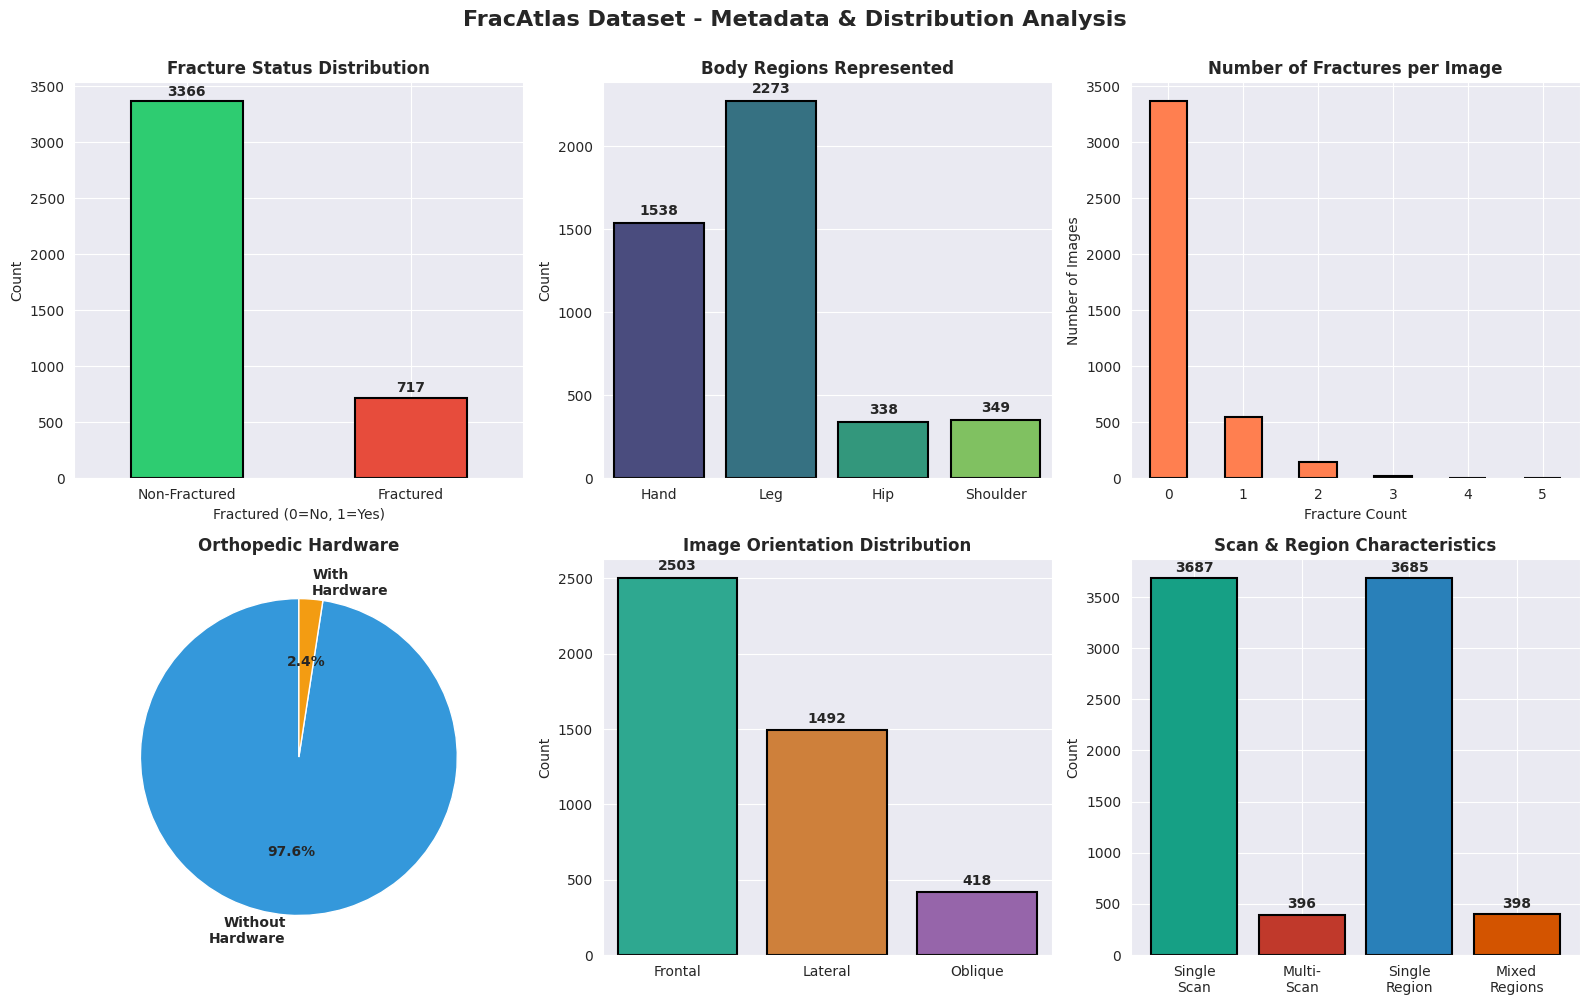

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('FracAtlas Dataset - Metadata & Distribution Analysis',
             fontsize=16, fontweight='bold', y=1.00)

# Plot 1: Fracture Distribution
colors_fracture = ['#2ecc71', '#e74c3c']
fracture_dist.plot(kind='bar', ax=axes[0, 0], color=colors_fracture, edgecolor='black', linewidth=1.5)
axes[0, 0].set_title('Fracture Status Distribution', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Fractured (0=No, 1=Yes)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xticklabels(['Non-Fractured', 'Fractured'], rotation=0)
for i, v in enumerate(fracture_dist):
    axes[0, 0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Plot 2: Body Regions
region_data = {r.capitalize(): df[r].sum() for r in regions}
sns.barplot(x=list(region_data.keys()), y=list(region_data.values()),
            ax=axes[0, 1], palette='viridis', edgecolor='black', linewidth=1.5)
axes[0, 1].set_title('Body Regions Represented', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xlabel('')
for i, (k, v) in enumerate(region_data.items()):
    axes[0, 1].text(i, v + 50, str(int(v)), ha='center', fontweight='bold')

# Plot 3: Fracture Count
fracture_count_dist.plot(kind='bar', ax=axes[0, 2], color='coral', edgecolor='black', linewidth=1.5)
axes[0, 2].set_title('Number of Fractures per Image', fontweight='bold', fontsize=12)
axes[0, 2].set_xlabel('Fracture Count')
axes[0, 2].set_ylabel('Number of Images')
axes[0, 2].set_xticklabels(fracture_count_dist.index, rotation=0)

# Plot 4: Hardware Presence
hardware_labels = ['Without\nHardware', 'With\nHardware']
hardware_values = [hardware_0, hardware_1]
colors_hw = ['#3498db', '#f39c12']
axes[1, 0].pie(hardware_values, labels=hardware_labels, autopct='%1.1f%%',
               colors=colors_hw, startangle=90, textprops={'fontweight': 'bold'})
axes[1, 0].set_title('Orthopedic Hardware', fontweight='bold', fontsize=12)

# Plot 5: Image Orientation
orientation_labels = ['Frontal', 'Lateral', 'Oblique']
orientation_values = [int(frontal), int(lateral), int(oblique)]
colors_orient = ['#1abc9c', '#e67e22', '#9b59b6']
sns.barplot(x=orientation_labels, y=orientation_values, ax=axes[1, 1],
            palette=colors_orient, edgecolor='black', linewidth=1.5)
axes[1, 1].set_title('Image Orientation Distribution', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xlabel('')
for i, v in enumerate(orientation_values):
    axes[1, 1].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Plot 6: Multi-scan & Mixed Regions
characteristics = ['Single\nScan', 'Multi-\nScan', 'Single\nRegion', 'Mixed\nRegions']
characteristics_values = [multiscan_0, multiscan_1, mixed_0, mixed_1]
colors_char = ['#16a085', '#c0392b', '#2980b9', '#d35400']
bars = axes[1, 2].bar(characteristics, characteristics_values, color=colors_char,
                       edgecolor='black', linewidth=1.5)
axes[1, 2].set_title('Scan & Region Characteristics', fontweight='bold', fontsize=12)
axes[1, 2].set_ylabel('Count')
for bar, val in zip(bars, characteristics_values):
    height = bar.get_height()
    axes[1, 2].text(bar.get_x() + bar.get_width()/2., height + 30,
                   f'{int(val)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/01_metadata_distribution.png', dpi=300, bbox_inches='tight')
print("Saved: 01_metadata_distribution.png")
plt.show()

## Visual - image sample

Saved: 02_sample_images.png


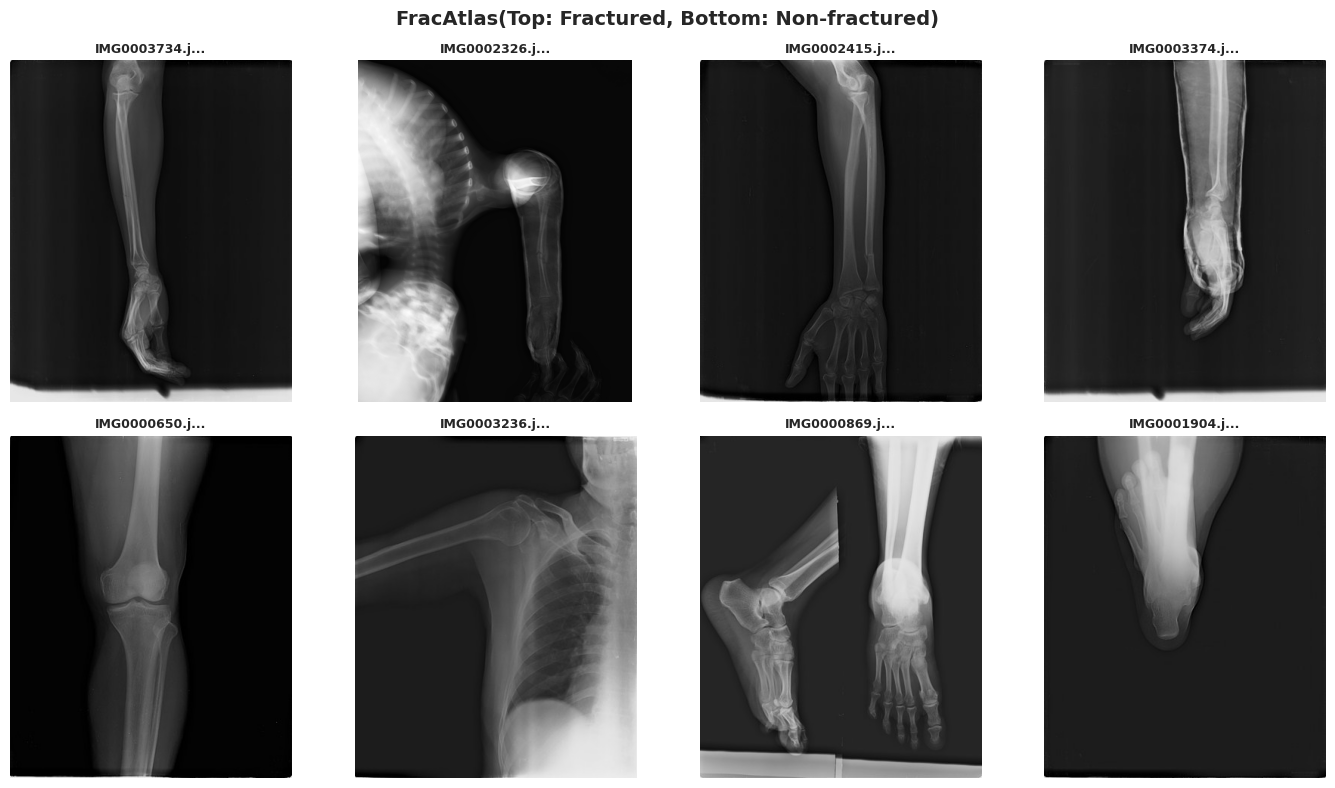

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
fig.suptitle('FracAtlas(Top: Fractured, Bottom: Non-fractured)',
             fontsize=14, fontweight='bold')

# Fractured samples
for idx in range(4):
    img_path = os.path.join(fractured_path, fractured_files[idx])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, idx].imshow(img)
    axes[0, idx].set_title(f'{fractured_files[idx][:12]}', fontsize=9, fontweight='bold')
    axes[0, idx].axis('off')

# Non-fractured samples
for idx in range(4):
    img_path = os.path.join(non_fractured_path, non_fractured_files[idx])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[1, idx].imshow(img)
    axes[1, idx].set_title(f'{non_fractured_files[idx][:12]}', fontsize=9, fontweight='bold')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/02_sample_images.png', dpi=300, bbox_inches='tight')
print("Saved: 02_sample_images.png")
plt.show()

## Visual- Image properties

Saved: 03_image_properties.png


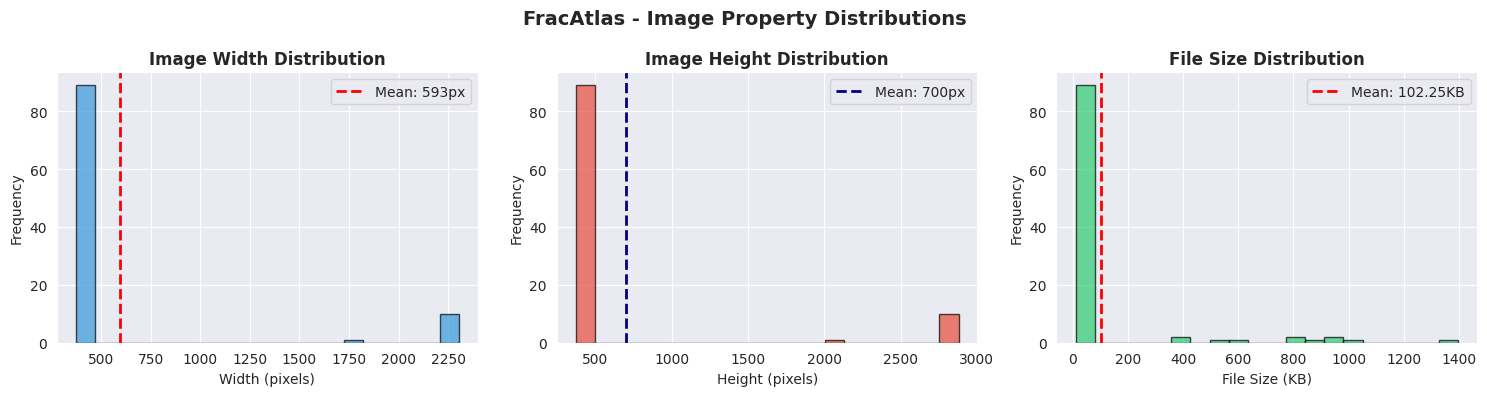

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('FracAtlas - Image Property Distributions', fontsize=14, fontweight='bold')

# Width distribution
axes[0].hist(image_stats['width'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Image Width Distribution', fontweight='bold')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(image_stats['width']), color='red', linestyle='--', linewidth=2, label=f"Mean: {np.mean(image_stats['width']):.0f}px")
axes[0].legend()

# Height distribution
axes[1].hist(image_stats['height'], bins=20, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].set_title('Image Height Distribution', fontweight='bold')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.mean(image_stats['height']), color='navy', linestyle='--', linewidth=2, label=f"Mean: {np.mean(image_stats['height']):.0f}px")
axes[1].legend()

# File size distribution
axes[2].hist(image_stats['file_size_kb'], bins=20, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[2].set_title('File Size Distribution', fontweight='bold')
axes[2].set_xlabel('File Size (KB)')
axes[2].set_ylabel('Frequency')
axes[2].axvline(np.mean(image_stats['file_size_kb']), color='red', linestyle='--', linewidth=2, label=f"Mean: {np.mean(image_stats['file_size_kb']):.2f}KB")
axes[2].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/03_image_properties.png', dpi=300, bbox_inches='tight')
print("Saved: 03_image_properties.png")
plt.show()

## Annotation analysis

In [ ]:
annotations_path = os.path.join(dataset_path, 'Annotations')

if os.path.exists(annotations_path):
    print(f"\n Available Annotation Formats:")
    for subdir in os.listdir(annotations_path):
        subdir_path = os.path.join(annotations_path, subdir)
        if os.path.isdir(subdir_path):
            num_files = len(os.listdir(subdir_path))
            print(f"   {subdir}: {num_files} files")

            # Detailed analysis for COCO JSON
            if subdir == 'COCO JSON':
                coco_files = [f for f in os.listdir(subdir_path) if f.endswith('.json')]
                if coco_files:
                    print(f"    └─ COCO JSON files: {coco_files}")
                    try:
                        with open(os.path.join(subdir_path, coco_files[0])) as f:
                            coco_data = json.load(f)
                            print(f"        Images: {len(coco_data.get('images', []))}")
                            print(f"        Annotations: {len(coco_data.get('annotations', []))}")
                            print(f"        Categories: {len(coco_data.get('categories', []))}")
                    except Exception as e:
                        print(f"    └─ Error reading COCO JSON: {e}")


 Available Annotation Formats:
  • VGG JSON: 1 files
  • PASCAL VOC: 4083 files
  • COCO JSON: 1 files
    └─ COCO JSON files: ['COCO_fracture_masks.json']
       • Images: 717
       • Annotations: 922
       • Categories: 1
  • YOLO: 4084 files


## Data quality report

In [ ]:
completeness = (1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100

print(f"\n DATA QUALITY METRICS:")
print(f"   Dataset Completeness: {completeness:.2f}%")
print(f"   Total Unique Images: {len(df):,}")
print(f"   Unique Image IDs: {df['image_id'].nunique():,}")
print(f"   Duplicate Check: {'No duplicates' if df['image_id'].nunique() == len(df) else ' Duplicates found'}")

print(f"\n CRITICAL ISSUES & RECOMMENDATIONS:")
print(f"  1. Class Imbalance: {imbalance_ratio:.2f}:1 ratio")
print(f"      Solution: Use SMOTE, weighted loss function, or data augmentation")
print(f"      Suggested class weights: Fracture={fracture_dist[0]/fracture_dist[1]:.2f}, Non-fracture=1.0")

print(f"\n  2. Image Dimension Variability:")
print(f"     Width range: {min(image_stats['width'])}-{max(image_stats['width'])}px")
print(f"     Height range: {min(image_stats['height'])}-{max(image_stats['height'])}px")
print(f"     Solution: Resize to 224×224px for EfficientNetB0/DenseNet121")

print(f"\n  3. Annotation Coverage:")
print(f"     COCO JSON annotations only for fractured images")
print(f"     Use for fracture localization in XAI (Grad-CAM)")

print(f"\n  4. Hardware Artifacts:")
print(f"     {hardware_1:,} images with orthopedic devices ({hardware_1/len(df)*100:.2f}%)")


 DATA QUALITY METRICS:
   Dataset Completeness: 100.00%
   Total Unique Images: 4,083
   Unique Image IDs: 4,083
   Duplicate Check: No duplicates

 CRITICAL ISSUES & RECOMMENDATIONS:
  1. Class Imbalance: 4.69:1 ratio
      Solution: Use SMOTE, weighted loss function, or data augmentation
      Suggested class weights: Fracture=4.69, Non-fracture=1.0

  2. Image Dimension Variability:
     Width range: 373-2304px
     Height range: 373-2880px
     Solution: Resize to 224×224px for EfficientNetB0/DenseNet121

  3. Annotation Coverage:
     COCO JSON annotations only for fractured images
     Use for fracture localization in XAI (Grad-CAM)

  4. Hardware Artifacts:
     99 images with orthopedic devices (2.42%)


## Summary save

In [ ]:
summary_data = {
    'Metric': [
        'Total Images',
        'Fractured Images',
        'Non-Fractured Images',
        'Imbalance Ratio',
        'Hand Images',
        'Leg Images',
        'Hip Images',
        'Shoulder Images',
        'Images with Hardware',
        'Images with Multiple Scans',
        'Images with Mixed Regions',
        'Frontal View Images',
        'Lateral View Images',
        'Oblique View Images',
        'Average Image Width (px)',
        'Average Image Height (px)',
        'Average File Size (KB)',
        'Dataset Completeness (%)'
    ],
    'Value': [
        f'{len(df):,}',
        f'{int(fracture_dist[1]):,}',
        f'{int(fracture_dist[0]):,}',
        f'{imbalance_ratio:.2f}:1',
        f'{int(df["hand"].sum()):,}',
        f'{int(df["leg"].sum()):,}',
        f'{int(df["hip"].sum()):,}',
        f'{int(df["shoulder"].sum()):,}',
        f'{hardware_1:,}',
        f'{multiscan_1:,}',
        f'{mixed_1:,}',
        f'{int(frontal):,}',
        f'{int(lateral):,}',
        f'{int(oblique):,}',
        f'{np.mean(image_stats["width"]):.2f}',
        f'{np.mean(image_stats["height"]):.2f}',
        f'{np.mean(image_stats["file_size_kb"]):.2f}',
        f'{completeness:.2f}'
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('/kaggle/working/EDA_Summary_Statistics.csv', index=False)
print(" Saved: EDA_Summary_Statistics.csv")
print(f"\nSummary Statistics:")
print(summary_df.to_string(index=False))

 Saved: EDA_Summary_Statistics.csv

Summary Statistics:
                    Metric  Value
              Total Images  4,083
          Fractured Images    717
      Non-Fractured Images  3,366
           Imbalance Ratio 4.69:1
               Hand Images  1,538
                Leg Images  2,273
                Hip Images    338
           Shoulder Images    349
      Images with Hardware     99
Images with Multiple Scans    396
 Images with Mixed Regions    398
       Frontal View Images  2,503
       Lateral View Images  1,492
       Oblique View Images    418
  Average Image Width (px) 592.60
 Average Image Height (px) 699.59
    Average File Size (KB) 102.25
  Dataset Completeness (%) 100.00


In [ ]:
df.head(10).to_csv('/kaggle/working/dataset_sample.csv', index=False)
print(" Saved: dataset_sample.csv")

 Saved: dataset_sample.csv


# Pre-Processing

In [ ]:
import pandas as pd
import numpy as np
import cv2
import os
import json
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

## Configuration

In [ ]:
CONFIG = {
    'dataset_path': '/kaggle/input/fracatlas-original-dataset/FracAtlas',
    'output_path': '/kaggle/working/preprocessed_data',
    'image_size': (224, 224),
    'train_split': 0.70,
    'val_split': 0.15,
    'test_split': 0.15,
    'random_state': 42,
    'augmentation': True,
    'use_clahe': True,
}

print(f"\nConfiguration:")
for key, value in CONFIG.items():
    if key != 'dataset_path':
        print(f"  {key}: {value}")


Configuration:
  output_path: /kaggle/working/preprocessed_data
  image_size: (224, 224)
  train_split: 0.7
  val_split: 0.15
  test_split: 0.15
  random_state: 42
  augmentation: True
  use_clahe: True


In [ ]:
output_dirs = {
    'images': os.path.join(CONFIG['output_path'], 'images'),
    'train': os.path.join(CONFIG['output_path'], 'images', 'train'),
    'val': os.path.join(CONFIG['output_path'], 'images', 'val'),
    'test': os.path.join(CONFIG['output_path'], 'images', 'test'),
    'metadata': os.path.join(CONFIG['output_path'], 'metadata'),
    'plots': os.path.join(CONFIG['output_path'], 'plots'),
}

for dir_name, dir_path in output_dirs.items():
    os.makedirs(dir_path, exist_ok=True)
    print(f"Created: {dir_path}")


Created: /kaggle/working/preprocessed_data/images
Created: /kaggle/working/preprocessed_data/images/train
Created: /kaggle/working/preprocessed_data/images/val
Created: /kaggle/working/preprocessed_data/images/test
Created: /kaggle/working/preprocessed_data/metadata
Created: /kaggle/working/preprocessed_data/plots


In [ ]:
csv_path = os.path.join(CONFIG['dataset_path'], 'dataset.csv')
df = pd.read_csv(csv_path)

print(f" Loaded dataset: {len(df)} images")
print(f"  Columns: {len(df.columns)}")


 Loaded dataset: 4083 images
  Columns: 13


## Image Pre process function

In [ ]:
def apply_clahe(image):

    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    return enhanced

def preprocess_image(image_path, target_size=(224, 224), apply_clahe_flag=True):

    try:
        # Load image
        image = cv2.imread(image_path)

        if image is None:
            return None


        if apply_clahe_flag:
            image = apply_clahe(image)

            if len(image.shape) == 2:
                image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

        # Resize image
        resized = cv2.resize(image, target_size, interpolation=cv2.INTER_LINEAR)

        normalized = resized.astype(np.float32) / 255.0

        return normalized

    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

def augment_image(image):

    augmented_images = [image.copy()]

    # 1. Rotation augmentation
    angles = [-20, -10, 0, 10, 20]
    for angle in angles:
        if angle != 0:
            h, w = image.shape[:2]
            center = (w // 2, h // 2)
            matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
            rotated = cv2.warpAffine(image, matrix, (w, h), borderMode=cv2.BORDER_REFLECT)
            augmented_images.append(rotated)

    # 2. Horizontal flip
    flipped_h = cv2.flip(image, 1)
    augmented_images.append(flipped_h)

    # 3. Vertical flip
    flipped_v = cv2.flip(image, 0)
    augmented_images.append(flipped_v)

    # 4. Zoom augmentation
    h, w = image.shape[:2]
    zoom_factor = 1.1
    crop_h, crop_w = int(h / zoom_factor), int(w / zoom_factor)
    start_y, start_x = (h - crop_h) // 2, (w - crop_w) // 2
    cropped = image[start_y:start_y+crop_h, start_x:start_x+crop_w]
    zoomed = cv2.resize(cropped, (w, h))
    augmented_images.append(zoomed)

    return augmented_images


## loading PreProcessed images

In [ ]:
fractured_path = os.path.join(CONFIG['dataset_path'], 'images', 'Fractured')
non_fractured_path = os.path.join(CONFIG['dataset_path'], 'images', 'Non_fractured')

preprocessed_data = []
processed_count = 0
error_count = 0

print("\nProcessing Fractured Images...")
fractured_files = [f for f in os.listdir(fractured_path) if f.endswith('.jpg')]
for idx, img_file in enumerate(fractured_files):
    img_path = os.path.join(fractured_path, img_file)
    preprocessed_img = preprocess_image(img_path, CONFIG['image_size'], CONFIG['use_clahe'])

    if preprocessed_img is not None:
        preprocessed_data.append({
            'image_id': img_file,
            'image_data': preprocessed_img,
            'label': 1,
            'label_name': 'Fractured',
            'source': 'Fractured'
        })
        processed_count += 1
    else:
        error_count += 1

    if (idx + 1) % 500 == 0:
        print(f"  Processed: {idx + 1}/{len(fractured_files)}")

print(f" Processed Fractured images: {processed_count}")

print("\nProcessing Non-Fractured Images...")
non_fractured_files = [f for f in os.listdir(non_fractured_path) if f.endswith('.jpg')]
for idx, img_file in enumerate(non_fractured_files):
    img_path = os.path.join(non_fractured_path, img_file)
    preprocessed_img = preprocess_image(img_path, CONFIG['image_size'], CONFIG['use_clahe'])

    if preprocessed_img is not None:
        preprocessed_data.append({
            'image_id': img_file,
            'image_data': preprocessed_img,
            'label': 0,
            'label_name': 'Non_Fractured',
            'source': 'Non_fractured'
        })
        processed_count += 1
    else:
        error_count += 1

    if (idx + 1) % 500 == 0:
        print(f"  Processed: {idx + 1}/{len(non_fractured_files)}")

print(f"\n Total images processed: {len(preprocessed_data)}")
print(f" Errors encountered: {error_count}")



Processing Fractured Images...
  Processed: 500/717
✓ Processed Fractured images: 717

Processing Non-Fractured Images...


Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file


  Processed: 500/3366


Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file


  Processed: 1000/3366


...

  Processed: 2500/3366


Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file


  Processed: 3000/3366


Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file



 Total images processed: 4083
 Errors encountered: 0


## Train Split sets

In [ ]:
# Extract labels for stratified split
labels = [item['label'] for item in preprocessed_data]
image_data = list(range(len(preprocessed_data)))

# First split
train_indices, temp_indices = train_test_split(
    image_data,
    test_size=0.30,
    stratify=labels,
    random_state=CONFIG['random_state']
)

# Second split
val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    stratify=[labels[i] for i in temp_indices],
    random_state=CONFIG['random_state']
)

# Create split mapping
split_mapping = {}
for idx in train_indices:
    split_mapping[preprocessed_data[idx]['image_id']] = 'train'
for idx in val_indices:
    split_mapping[preprocessed_data[idx]['image_id']] = 'val'
for idx in test_indices:
    split_mapping[preprocessed_data[idx]['image_id']] = 'test'

# Print split statistics
train_labels = [labels[i] for i in train_indices]
val_labels = [labels[i] for i in val_indices]
test_labels = [labels[i] for i in test_indices]

print(f"\n Train Set ({len(train_indices)} images, {len(train_indices)/len(preprocessed_data)*100:.1f}%):")
print(f"  Fractured: {sum(train_labels)} ({sum(train_labels)/len(train_labels)*100:.2f}%)")
print(f"  Non-Fractured: {len(train_labels) - sum(train_labels)} ({(len(train_labels) - sum(train_labels))/len(train_labels)*100:.2f}%)")

print(f"\nValidation Set ({len(val_indices)} images, {len(val_indices)/len(preprocessed_data)*100:.1f}%):")
print(f"  Fractured: {sum(val_labels)} ({sum(val_labels)/len(val_labels)*100:.2f}%)")
print(f"  Non-Fractured: {len(val_labels) - sum(val_labels)} ({(len(val_labels) - sum(val_labels))/len(val_labels)*100:.2f}%)")

print(f"\n Test Set ({len(test_indices)} images, {len(test_indices)/len(preprocessed_data)*100:.1f}%):")
print(f"  Fractured: {sum(test_labels)} ({sum(test_labels)/len(test_labels)*100:.2f}%)")
print(f"  Non-Fractured: {len(test_labels) - sum(test_labels)} ({(len(test_labels) - sum(test_labels))/len(test_labels)*100:.2f}%)")


 Train Set (2858 images, 70.0%):
  Fractured: 502 (17.56%)
  Non-Fractured: 2356 (82.44%)

Validation Set (612 images, 15.0%):
  Fractured: 107 (17.48%)
  Non-Fractured: 505 (82.52%)

 Test Set (613 images, 15.0%):
  Fractured: 108 (17.62%)
  Non-Fractured: 505 (82.38%)


## Data Augmentation

In [ ]:
augmented_data = []
augmentation_factor = 0

if CONFIG['augmentation']:
    print(f"\nAugmentation enabled - creating {len(train_indices)} × augmented versions")

    for train_idx in train_indices:
        original_item = preprocessed_data[train_idx]

        # Add original image
        augmented_data.append({
            'image_id': original_item['image_id'],
            'image_data': original_item['image_data'],
            'label': original_item['label'],
            'label_name': original_item['label_name'],
            'split': 'train',
            'augmented': False
        })

        # Generate augmented versions
        if original_item['label'] == 1:  # Focus augmentation on minority class (Fractured)
            augmented_imgs = augment_image((original_item['image_data'] * 255).astype(np.uint8))

            for aug_idx, aug_img in enumerate(augmented_imgs[1:], 1):  # Skip original
                normalized_aug = aug_img.astype(np.float32) / 255.0
                augmented_data.append({
                    'image_id': f"{original_item['image_id'].split('.')[0]}_aug{aug_idx}.jpg",
                    'image_data': normalized_aug,
                    'label': original_item['label'],
                    'label_name': original_item['label_name'],
                    'split': 'train',
                    'augmented': True
                })
                augmentation_factor += 1
        else:
            # For non-fractured
            aug_imgs = augment_image((original_item['image_data'] * 255).astype(np.uint8))
            normalized_aug = (aug_imgs[6].astype(np.float32) / 255.0)
            augmented_data.append({
                'image_id': f"{original_item['image_id'].split('.')[0]}_aug1.jpg",
                'image_data': normalized_aug,
                'label': original_item['label'],
                'label_name': original_item['label_name'],
                'split': 'train',
                'augmented': True
            })

    # Add validation set (no augmentation)
    for val_idx in val_indices:
        original_item = preprocessed_data[val_idx]
        augmented_data.append({
            'image_id': original_item['image_id'],
            'image_data': original_item['image_data'],
            'label': original_item['label'],
            'label_name': original_item['label_name'],
            'split': 'val',
            'augmented': False
        })

    # Add test set (no augmentation)
    for test_idx in test_indices:
        original_item = preprocessed_data[test_idx]
        augmented_data.append({
            'image_id': original_item['image_id'],
            'image_data': original_item['image_data'],
            'label': original_item['label'],
            'label_name': original_item['label_name'],
            'split': 'test',
            'augmented': False
        })

print(f" Augmentation complete:")
print(f"  Original training samples: {len(train_indices)}")
print(f"  Augmented samples created: {augmentation_factor}")
print(f"  Total training dataset (with augmentation): {len([x for x in augmented_data if x['split'] == 'train'])}")


Augmentation enabled - creating 2858 × augmented versions
 Augmentation complete:
  Original training samples: 2858
  Augmented samples created: 3514
  Total training dataset (with augmentation): 8728


## Save image data

In [ ]:
# Create metadata dataframe
metadata_list = []

print("\nSaving images and metadata...")
save_count = 0

for item in augmented_data:
    split = item['split']
    image_filename = item['image_id']
    image_path = os.path.join(output_dirs[split], image_filename)

    # Save image as NPZ
    image_npz_path = image_path.replace('.jpg', '.npz')
    np.savez_compressed(image_npz_path, image=item['image_data'])

    # Add to metadata
    metadata_list.append({
        'image_id': image_filename,
        'image_path': image_npz_path,
        'label': item['label'],
        'label_name': item['label_name'],
        'split': split,
        'augmented': item['augmented'],
        'shape': item['image_data'].shape,
        'dtype': str(item['image_data'].dtype)
    })

    save_count += 1

    if save_count % 500 == 0:
        print(f"  Saved: {save_count} images")

print(f" Total images saved: {save_count}")


Saving images and metadata...
  Saved: 500 images
  Saved: 1000 images
  Saved: 1500 images
  Saved: 2000 images
  Saved: 2500 images
  Saved: 3000 images
  Saved: 3500 images
  Saved: 4000 images
  Saved: 4500 images
  Saved: 5000 images
  Saved: 5500 images
  Saved: 6000 images
  Saved: 6500 images
  Saved: 7000 images
  Saved: 7500 images
  Saved: 8000 images
  Saved: 8500 images
  Saved: 9000 images
  Saved: 9500 images
 Total images saved: 9953


## Metadata

In [ ]:
metadata_df = pd.DataFrame(metadata_list)

# Save metadata
metadata_df.to_csv(
    os.path.join(output_dirs['metadata'], 'complete_metadata.csv'),
    index=False
)
print(" Saved: complete_metadata.csv")

# Save split-wise metadata
for split in ['train', 'val', 'test']:
    split_df = metadata_df[metadata_df['split'] == split].copy()
    split_df.to_csv(
        os.path.join(output_dirs['metadata'], f'{split}_metadata.csv'),
        index=False
    )
    print(f" Saved: {split}_metadata.csv ({len(split_df)} images)")


 Saved: complete_metadata.csv
 Saved: train_metadata.csv (8728 images)
 Saved: val_metadata.csv (612 images)
 Saved: test_metadata.csv (613 images)


## Label Encoding mapping

In [ ]:
label_mapping = {
    0: 'Non_Fractured',
    1: 'Fractured'
}

inverse_mapping = {v: k for k, v in label_mapping.items()}

print(f"\n Label Encoding:")
for code, label in label_mapping.items():
    count = (metadata_df['label'] == code).sum()
    print(f"  {label}: {code} ({count} images, {count/len(metadata_df)*100:.2f}%)")

# Save label mapping
with open(os.path.join(output_dirs['metadata'], 'label_mapping.json'), 'w') as f:
    json.dump({
        'label_to_class': label_mapping,
        'class_to_label': inverse_mapping
    }, f, indent=4)
print(" Saved: label_mapping.json")


 Label Encoding:
  Non_Fractured: 0 (5722 images, 57.49%)
  Fractured: 1 (4231 images, 42.51%)
 Saved: label_mapping.json


## Class Balance statistics

In [ ]:
for split in ['train', 'val', 'test']:
    split_df = metadata_df[metadata_df['split'] == split]
    label_counts = split_df['label'].value_counts().sort_index()

    print(f"\n{split.upper()} Set ({len(split_df)} images):")
    for label, count in label_counts.items():
        label_name = label_mapping[label]
        pct = count / len(split_df) * 100
        print(f"  {label_name}: {count} ({pct:.2f}%)")

    if label_counts.min() > 0:
        imbalance_ratio = label_counts.max() / label_counts.min()
        print(f"  Imbalance Ratio: {imbalance_ratio:.2f}:1")


TRAIN Set (8728 images):
  Non_Fractured: 4712 (53.99%)
  Fractured: 4016 (46.01%)
  Imbalance Ratio: 1.17:1

VAL Set (612 images):
  Non_Fractured: 505 (82.52%)
  Fractured: 107 (17.48%)
  Imbalance Ratio: 4.72:1

TEST Set (613 images):
  Non_Fractured: 505 (82.38%)
  Fractured: 108 (17.62%)
  Imbalance Ratio: 4.68:1


## Visualization

 Saved: preprocessed_samples.png


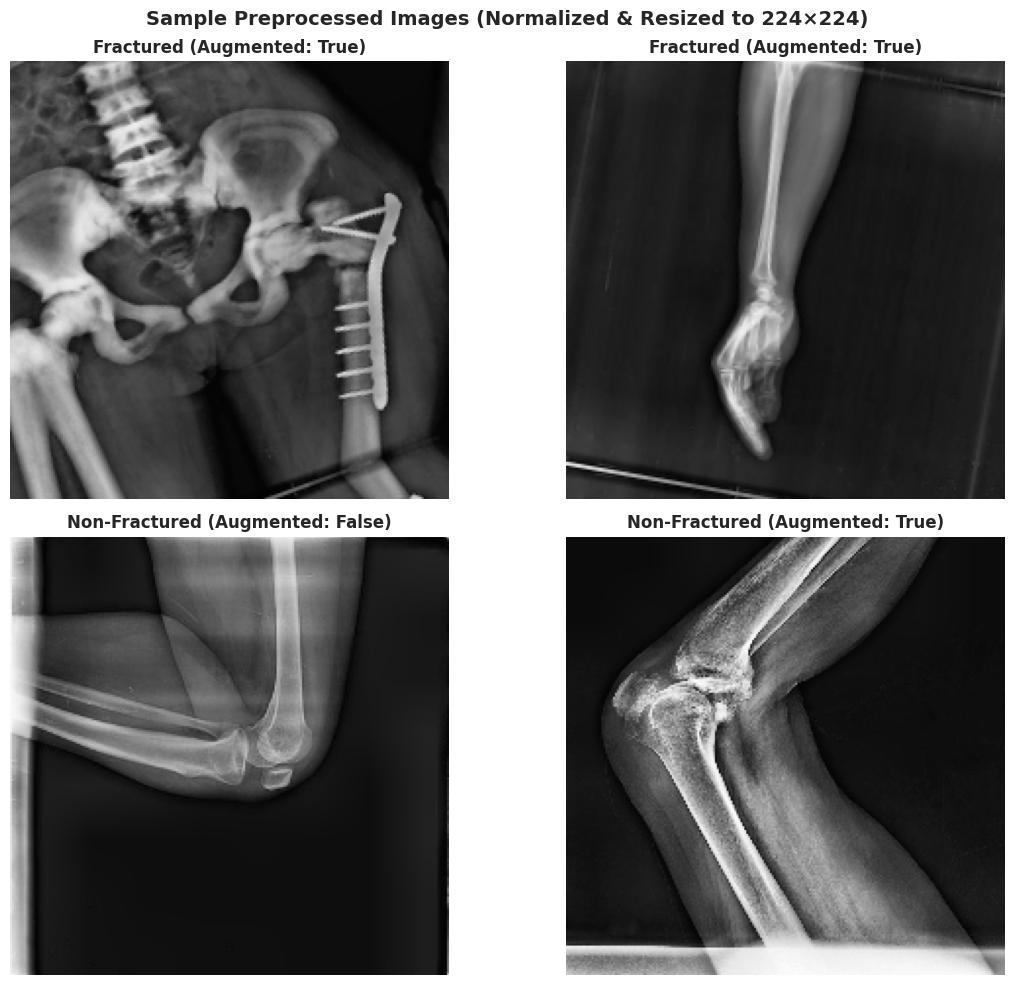

In [ ]:
sample_indices = {
    'train_fractured': np.random.choice(
        np.where((metadata_df['split'] == 'train') & (metadata_df['label'] == 1))[0], 2, replace=False
    ),
    'train_non_fractured': np.random.choice(
        np.where((metadata_df['split'] == 'train') & (metadata_df['label'] == 0))[0], 2, replace=False
    ),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Sample Preprocessed Images (Normalized & Resized to 224×224)',
             fontsize=14, fontweight='bold')

# Plot fractured
for idx, sample_idx in enumerate(sample_indices['train_fractured']):
    item = metadata_df.iloc[sample_idx]
    img_path = item['image_path']
    img = np.load(img_path)['image']

    # Convert to displayable format
    display_img = (img * 255).astype(np.uint8)
    if len(display_img.shape) == 3 and display_img.shape[2] == 3:
        display_img = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)

    axes[0, idx].imshow(display_img, cmap='gray' if len(display_img.shape) == 2 else None)
    axes[0, idx].set_title(f"Fractured (Augmented: {item['augmented']})", fontweight='bold')
    axes[0, idx].axis('off')

# Plot non-fractured
for idx, sample_idx in enumerate(sample_indices['train_non_fractured']):
    item = metadata_df.iloc[sample_idx]
    img_path = item['image_path']
    img = np.load(img_path)['image']

    # Convert to displayable format
    display_img = (img * 255).astype(np.uint8)
    if len(display_img.shape) == 3 and display_img.shape[2] == 3:
        display_img = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)

    axes[1, idx].imshow(display_img, cmap='gray' if len(display_img.shape) == 2 else None)
    axes[1, idx].set_title(f"Non-Fractured (Augmented: {item['augmented']})", fontweight='bold')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dirs['plots'], 'preprocessed_samples.png'), dpi=300, bbox_inches='tight')
print(" Saved: preprocessed_samples.png")
plt.show()

## Split distribution plots

 Saved: split_distribution.png


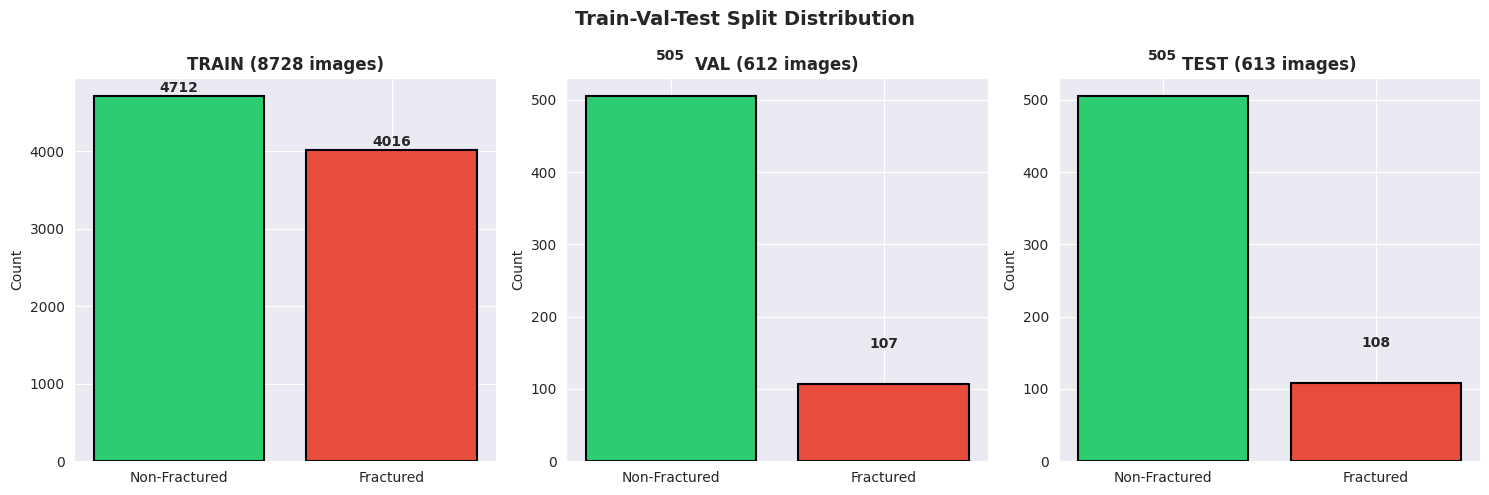

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Train-Val-Test Split Distribution', fontsize=14, fontweight='bold')

for idx, split in enumerate(['train', 'val', 'test']):
    split_df = metadata_df[metadata_df['split'] == split]
    label_counts = split_df['label'].value_counts().sort_index()

    colors = ['#2ecc71', '#e74c3c']
    labels = ['Non-Fractured', 'Fractured']

    axes[idx].bar([labels[i] for i in label_counts.index], label_counts.values, color=colors, edgecolor='black', linewidth=1.5)
    axes[idx].set_title(f'{split.upper()} ({len(split_df)} images)', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('Count')

    for i, (label_idx, count) in enumerate(label_counts.items()):
        axes[idx].text(i, count + 50, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_dirs['plots'], 'split_distribution.png'), dpi=300, bbox_inches='tight')
print(" Saved: split_distribution.png")
plt.show()


## Save confg

In [ ]:

config_json = {
    'image_size': CONFIG['image_size'],
    'train_split': CONFIG['train_split'],
    'val_split': CONFIG['val_split'],
    'test_split': CONFIG['test_split'],
    'random_state': CONFIG['random_state'],
    'augmentation_enabled': CONFIG['augmentation'],
    'clahe_enabled': CONFIG['use_clahe'],
    'total_preprocessed_images': len(augmented_data),
    'output_path': CONFIG['output_path']
}

with open(os.path.join(output_dirs['metadata'], 'preprocessing_config.json'), 'w') as f:
    json.dump(config_json, f, indent=4)

print(" Saved: preprocessing_config.json")

 Saved: preprocessing_config.json


In [ ]:
print(f"\nFinal Statistics:")
print(f"  Total preprocessed images: {len(augmented_data)}")
print(f"  Original images: {len(preprocessed_data)}")
print(f"  Augmented images: {len(augmented_data) - len(preprocessed_data)}")
print(f"  Output location: {CONFIG['output_path']}")

print(f"\nOutput Structure")
print(f"  train  ({len([x for x in augmented_data if x['split'] == 'train'])} .npz files)")
print(f"  val   ({len([x for x in augmented_data if x['split'] == 'val'])} .npz files)")
print(f"  test  ({len([x for x in augmented_data if x['split'] == 'test'])} .npz files)")


Final Statistics:
  Total preprocessed images: 9953
  Original images: 4083
  Augmented images: 5870
  Output location: /kaggle/working/preprocessed_data

Output Structure
  train  (8728 .npz files)
  val   (612 .npz files)
  test  (613 .npz files)
